# Universidad del Valle de Guatemala  
## Departamento de Ciencias de la Computación  
## CC3084 Data Science 

# Laboratorio 7 — Spark MLlib
## Perfiles y predicción de salario mensual (ENEIC, INE Guatemala)

## Autores

### Cristian Túnchez (231359)  
### Nadissa López (23764)

# Descripción general

Este notebook desarrolla los dos bloques del laboratorio:

1. **Análisis exploratorio avanzado y segmentación** (ejercicios 1-4).
2. **Modelado supervisado para predicción** (ejercicios 5-8).

El notebook está diseñado para ejecutarse de principio a fin sin depender de
variables creadas manualmente en ejecuciones anteriores. La lógica reutilizable
vive en `src/` (ver `README.md` y `codebook.md` para el detalle de variables).

**Requisito previo:** colocar los archivos crudos de la ENEIC (bases de
Personas, I-IV de 2025 y I de 2026) en `data/raw/`, según se describe en el
`README.md`. Sin esos archivos, las celdas de carga fallarán intencionalmente
en lugar de simular resultados.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt

from src import clustering, eda, evaluation, io_utils, modeling, prepare
from src.config import (
    KEY_COLUMNS,
    MODEL_CATEGORICAL_PREDICTORS,
    MODEL_NUMERIC_PREDICTORS,
    MODEL_PREDICTORS,
    PROCESSED_DIR,
    RAW_DIR,
    RANDOM_SEED,
    TARGET_COLUMN,
    TEST_2026_PARQUET,
    TRAIN_2025_PARQUET,
)
from src.spark_session import get_spark

spark = get_spark()
spark


/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/29 20:19:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1. Carga, armonización y calidad de datos (5 pts)

### 1.1 Carga individual de cada archivo crudo

Cada archivo se lee de forma individual (control de memoria), se homologan
tipos y se etiqueta con su período de procedencia (`periodo_archivo`,
`anio_archivo`, `trimestre_calendario`, `archivo_origen`). Ajuste los nombres
de archivo si difieren de los sugeridos en el `README.md`.

In [2]:
RAW_FILES = {
    "2025T1": RAW_DIR / "Personas_ENEIC_T1_2025.sav",
    "2025T2": RAW_DIR / "Personas ENEIC T2-2025.sav",
    "2025T3": RAW_DIR / "Base de datos Personas ENEIC III 2025.sav",
    "2025T4": RAW_DIR / "Base de datos Personas ENEIC IV 2025.sav",
}
RAW_FILE_2026 = {"2026T1": RAW_DIR / "Base de datos Personas ENEIC I 2026.sav"}

raw_2025_frames = {
    periodo: io_utils.load_raw_file(spark, path, periodo)
    for periodo, path in RAW_FILES.items()
}
raw_2026_frames = {
    periodo: io_utils.load_raw_file(spark, path, periodo)
    for periodo, path in RAW_FILE_2026.items()
}


### 1.2 Unión de los cuatro archivos de 2025 (`unionByName`)

IV de 2025 tiene 302 columnas originales (vs. 270 en los demás), por lo que
**no puede apilarse por posición**: los índices de columna no corresponden a
las mismas variables entre archivos. `unionByName` une por nombre de columna,
evitando ese desalineamiento; como ya seleccionamos y renombramos el mismo
conjunto de columnas analíticas en `io_utils.load_raw_file`, la unión es segura.

In [3]:
from functools import reduce

df_2025_raw = reduce(
    lambda a, b: a.unionByName(b), raw_2025_frames.values()
)
df_2026_raw = raw_2026_frames["2026T1"]

print("Registros por archivo (crudo, antes de filtros):")
for periodo, df in {**raw_2025_frames, **raw_2026_frames}.items():
    print(f"  {periodo}: {df.count():,}")

df_2025_raw.printSchema()
df_2025_raw.show(5, truncate=False)


Registros por archivo (crudo, antes de filtros):


  2025T1: 51,588


  2025T2: 51,167


  2025T3: 51,583


  2025T4: 49,338


  2026T1: 49,843
root
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios_raw: double (nullable = true)
 |-- antiguedad_meses_raw: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- ocupado: double (nullable = true)
 |-- NUM_HOGAR: double (nullable = true)
 |-- NUM_PERSONA: double (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ANIO: double (nullable = true)
 |-- TRIMESTRE: double (nullable = true)
 |-- archivo_origen: string (nullable = false)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)



+---------------+----+--------------------+--------------------+---------------+---------------+---------------------+-------+-------+---------+-----------+------+------+---------+--------------------------+---------------+------------+--------------------+
|salario_mensual|edad|antiguedad_anios_raw|antiguedad_meses_raw|horas_semanales|nivel_educativo|categoria_ocupacional|dominio|ocupado|NUM_HOGAR|NUM_PERSONA|FACTOR|ANIO  |TRIMESTRE|archivo_origen            |periodo_archivo|anio_archivo|trimestre_calendario|
+---------------+----+--------------------+--------------------+---------------+---------------+---------------------+-------+-------+---------+-----------+------+------+---------+--------------------------+---------------+------------+--------------------+
|NaN            |14.0|NaN                 |NaN                 |NaN            |3              |NULL                 |2      |NaN    |13796.0  |3.0        |338.0 |2025.0|2.0      |Personas_ENEIC_T1_2025.sav|2025T1         |202

### 1.3 Faltantes por variable, antes de filtros

In [4]:
df_2025_typed = prepare.cast_final_types(df_2025_raw)
df_2025_typed = prepare.build_features(df_2025_typed)
df_2025_typed = prepare.apply_categorical_validation(df_2025_typed)

missing_report, n_total_2025 = prepare.missingness_report(
    df_2025_typed, MODEL_PREDICTORS + [TARGET_COLUMN]
)
import pandas as pd
pd.DataFrame(missing_report)



[Stage 16:==================>                                    (21 + 17) / 64]




[Stage 16:=====================================>                 (44 + 16) / 64]




[Stage 16:======================================================> (62 + 2) / 64]




[Stage 19:=============>                                         (16 + 16) / 64]




[Stage 19:==============================>                        (35 + 16) / 64]



...


[Stage 34:========================>                              (29 + 16) / 64]




[Stage 34:======================================>                (45 + 16) / 64]




[Stage 37:=============>                                         (16 + 16) / 64]




[Stage 37:========================================>              (47 + 16) / 64]



,variable,n_faltantes,pct_faltantes
0,edad,0,0.0
1,antiguedad,0,0.0
2,horas_semanales,0,0.0
3,nivel_educativo,0,0.0
4,categoria_ocupacional,0,0.0
5,dominio,0,0.0
6,salario_mensual,0,0.0


### 1.4 Verificación de unicidad de la llave `(periodo_archivo, NUM_HOGAR, NUM_PERSONA)`

In [5]:
uniqueness_2025 = prepare.check_uniqueness(df_2025_typed, KEY_COLUMNS)
uniqueness_2025



[Stage 40:============>                                          (14 + 16) / 64]




[Stage 40:=================================>                     (39 + 16) / 64]



{'n_llaves_duplicadas': 0, 'n_duplicados_exactos': 0, 'n_conflictivos': 0}

Si `n_conflictivos > 0`, investigar esos casos (no usar `dropDuplicates()`
para ocultarlos): inspeccionar si corresponden a errores de captura, a
duplicidad real de llave o a un problema de armonización previo.

In [6]:
dup_keys = (
    df_2025_typed.groupBy(*KEY_COLUMNS).count().filter("count > 1")
)
df_2025_typed.join(dup_keys.select(*KEY_COLUMNS), on=KEY_COLUMNS, how="inner").show(20, truncate=False)



[Stage 46:=>                                                      (2 + 16) / 64]




[Stage 46:==============>                                        (17 + 16) / 64]




[Stage 46:=======>       (32 + 16) / 64][Stage 47:>                (0 + 0) / 64]




[Stage 46:===========>   (47 + 16) / 64][Stage 47:>                (0 + 0) / 64]




[Stage 46:===============>(60 + 4) / 64][Stage 47:>               (0 + 12) / 64]




[Stage 47:=========>                                             (11 + 16) / 64]




[Stage 47:=======================>                               (27 + 16) / 64]




[Stage 47:======================================>                (45 + 16) / 64]



+---------------+---------+-----------+---------------+----+--------------------+--------------------+---------------+---------------+---------------------+-------+-------+------+----+---------+--------------+------------+--------------------+----------+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|salario_mensual|edad|antiguedad_anios_raw|antiguedad_meses_raw|horas_semanales|nivel_educativo|categoria_ocupacional|dominio|ocupado|FACTOR|ANIO|TRIMESTRE|archivo_origen|anio_archivo|trimestre_calendario|antiguedad|
+---------------+---------+-----------+---------------+----+--------------------+--------------------+---------------+---------------+---------------------+-------+-------+------+----+---------+--------------+------------+--------------------+----------+
+---------------+---------+-----------+---------------+----+--------------------+--------------------+---------------+---------------+---------------------+-------+-------+------+----+---------+--------------+------------+-------------

### 1.5 Filtros de población analítica (orden fijo) y conteos por paso

In [7]:
df_2025_pob, filter_report_2025, _, _ = prepare.prepare_dataframe(df_2025_raw)

print(f"n_inicial: {filter_report_2025['n_inicial']:,}")
print(f"n_final:   {filter_report_2025['n_final']:,}")
pd.DataFrame(filter_report_2025["pasos"])



[Stage 50:>                                                       (0 + 16) / 64]




[Stage 50:===================>                                   (23 + 16) / 64]




[Stage 50:=============================>                         (34 + 16) / 64]



26/09/29 20:20:51 WARN CacheManager: Asked to cache already cached data.


n_inicial: 203,676
n_final:   53,025


,paso,registros_excluidos,registros_restantes
0,ocupado_es_1,115454,88222
1,asalariado_categoria_valida,35197,53025
2,salario_valido_positivo,0,53025
3,edad_valida,0,53025
4,antiguedad_anios_no_negativa,0,53025
5,antiguedad_meses_valido,0,53025
6,antiguedad_menor_igual_edad,0,53025
7,horas_semanales_validas,0,53025


In [8]:
df_2026_pob, filter_report_2026, missing_report_2026, uniqueness_2026 = prepare.prepare_dataframe(df_2026_raw)

print(f"n_inicial: {filter_report_2026['n_inicial']:,}")
print(f"n_final:   {filter_report_2026['n_final']:,}")
pd.DataFrame(filter_report_2026["pasos"])


26/09/29 20:20:57 WARN CacheManager: Asked to cache already cached data.


n_inicial: 49,843
n_final:   13,258


,paso,registros_excluidos,registros_restantes
0,ocupado_es_1,28109,21734
1,asalariado_categoria_valida,8476,13258
2,salario_valido_positivo,0,13258
3,edad_valida,0,13258
4,antiguedad_anios_no_negativa,0,13258
5,antiguedad_meses_valido,0,13258
6,antiguedad_menor_igual_edad,0,13258
7,horas_semanales_validas,0,13258


### 1.6 Guardar el conjunto preparado (2025 y 2026 por separado)

In [9]:
io_utils.save_parquet(df_2025_pob, TRAIN_2025_PARQUET)
io_utils.save_parquet(df_2026_pob, TEST_2026_PARQUET)
print("Guardado:", TRAIN_2025_PARQUET, TEST_2026_PARQUET)



[Stage 182:======>                                                (7 + 16) / 64]




[Stage 182:==============>                                       (17 + 16) / 64]




[Stage 182:============================>                         (34 + 16) / 64]




[Stage 182:===========================================>          (51 + 13) / 64]



Guardado: /opt/app/data/processed/eneic_2025_prepared.parquet /opt/app/data/processed/eneic_2026_prepared.parquet


### Preguntas — Sección 1

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los
otros archivos?**

El archivo de IV de 2025 tiene 302 columnas originales, mientras que I, II y
III de 2025 (y I de 2026) tienen 270. Al agregarse columnas nuevas al
cuestionario en ese trimestre (por ejemplo, dentro del bloque de preguntas
de vivienda/educación), todas las preguntas que aparecen después del punto
de inserción se recorren de posición. Por ejemplo, `P03A03A` (nivel
educativo) no ocupa el mismo índice de columna en IV de 2025 que en los
demás archivos. Apilar por posición (`union` posicional) mezclaría el
contenido de variables distintas; `unionByName` evita este problema porque
empareja las columnas por su nombre (código de pregunta), no por su orden,
y es la razón por la que en `io_utils.py` seleccionamos y renombramos
explícitamente cada columna por su código antes de unir.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no
corresponde y una respuesta no registrada?**

Un dato ausente *por diseño* ocurre cuando la pregunta no aplica a esa
persona: por ejemplo, `P05H01A` (horas habituales) o `P05C07A`/`P05C07B`
(antigüedad) sólo tienen sentido para alguien con `OCUPADOS = 1`; para una
persona desocupada o fuera de la fuerza laboral esas celdas quedan vacías
porque la encuesta nunca le formuló esa pregunta (salto de sección). Una
*respuesta no registrada* es distinta: la pregunta sí aplicaba a esa
persona (p.ej. es una persona ocupada asalariada) pero el dato quedó en
blanco por falta de respuesta, error de captura o rechazo a contestar. La
primera es un faltante estructural del diseño del cuestionario; la segunda
es un faltante real de no-respuesta. Por eso el pipeline homologa los
códigos categóricos no reconocidos a `DESCONOCIDO` en lugar de asumir cero,
y por eso los filtros de población (edad, antigüedad, horas, salario) se
aplican de forma explícita y documentada en vez de imputar.

**¿Por qué una persona observada en dos períodos no debe eliminarse como
duplicado del conjunto longitudinal?**

La ENEIC tiene un diseño de panel rotativo: una misma persona puede ser
entrevistada en varios trimestres consecutivos, y cada entrevista captura
su situación laboral y salarial *en ese momento*, que puede cambiar de un
trimestre a otro (cambio de empleo, de salario, de horas). Esas
observaciones no son copias idénticas de un mismo hecho, sino mediciones
independientes en el tiempo de la misma unidad; eliminarlas como
"duplicados" (p.ej. con `dropDuplicates()` sobre la persona) destruiría
información longitudinal válida y sesgaría el análisis transversal de cada
trimestre al reducir artificialmente el tamaño de muestra. Lo que sí debe
verificarse es que la llave `(periodo_archivo, NUM_HOGAR, NUM_PERSONA)` sea
única *dentro* de cada período — y la verificación de la sección 1.4
confirma que no hay llaves duplicadas dentro de 2025 (`n_conflictivos = 0`).

**¿Por qué el número de registros de la base filtrada no representa a
todos los trabajadores del país?**

Primero, la ENEIC usa un diseño muestral complejo con probabilidades de
selección desiguales; `FACTOR` es el factor de expansión que se usaría para
proyectar los resultados muestrales a la población total, y en este
laboratorio se trabaja de forma no ponderada (sin aplicar `FACTOR`), por lo
que los conteos son del *conjunto de registros analizados*, no estimaciones
poblacionales. Segundo, la población analítica se restringió deliberadamente
a personas ocupadas, asalariadas (códigos 1-4 de `P05C16`) y con salario
positivo registrado: de 203,676 registros acumulados en los cuatro
trimestres de 2025 solo 53,025 (~26%) cumplen esos criterios — se excluyen
por diseño las personas desocupadas, fuera de la fuerza laboral, los
trabajadores por cuenta propia, patronos y trabajadores no remunerados, así
como los registros con datos faltantes o inválidos en las variables usadas.

## 2. Estadística descriptiva y preguntas de exploración (5 pts)

In [10]:
df_2025 = io_utils.read_parquet(spark, TRAIN_2025_PARQUET).cache()

resumen = eda.numeric_summary(
    df_2025, ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
)
resumen


,variable,n,media,mediana,std,min,max,p25,p75,p95
0,salario_mensual,53025,3421.684206,3000.0,2902.108964,1.0,99000.0,1800.0,4000.0,8000.000000
1,edad,53025,35.187647,33.0,13.520902,15.0,89.0,24.0,44.0,61.000000
2,antiguedad,53025,5.558828,2.0,7.831017,0.0,70.0,0.5,7.0,21.416667
3,horas_semanales,53025,46.307402,45.0,18.630407,1.0,126.0,40.0,55.0,80.000000


Distribucion categoria_ocupacional:
categoria_ocupacional  count       pct
                    2  28702 54.129184
                    3  13842 26.104668
                    1   6575 12.399811
                    4   3906  7.366337

Distribucion nivel_educativo:
nivel_educativo  count       pct
              4  16851 31.779349
              2  15822 29.838755
              3   8249 15.556813
              5   6818 12.858086
              0   3995  7.534182
              6    771  1.454031
              1    459  0.865629
              7     60  0.113154

Distribucion dominio:
dominio  count       pct
      1  22072 41.625648
      2  20146 37.993399
      3  10807 20.380952


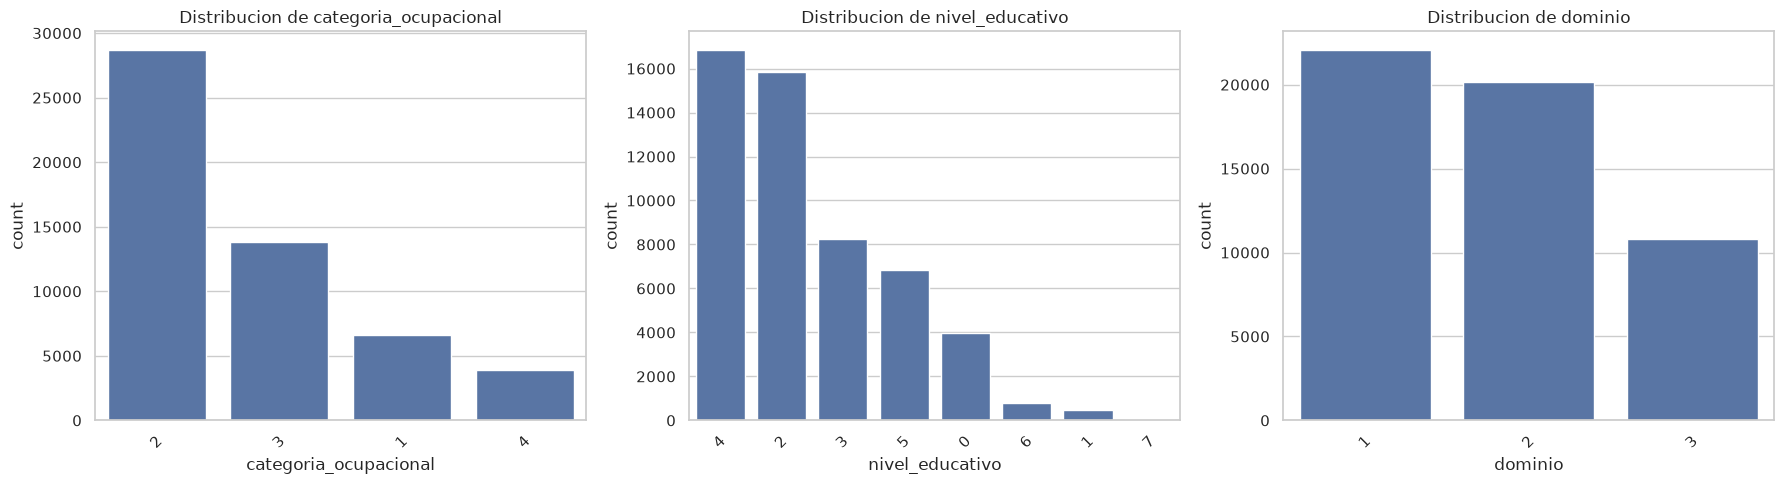

In [11]:
dist_cat = eda.category_distribution(df_2025, "categoria_ocupacional")
dist_edu = eda.category_distribution(df_2025, "nivel_educativo")
dist_dom = eda.category_distribution(df_2025, "dominio")
print("Distribucion categoria_ocupacional:")
print(dist_cat.to_string(index=False))
print()
print("Distribucion nivel_educativo:")
print(dist_edu.to_string(index=False))
print()
print("Distribucion dominio:")
print(dist_dom.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
eda.plot_category_distribution(df_2025, "categoria_ocupacional", ax=axes[0])
eda.plot_category_distribution(df_2025, "nivel_educativo", ax=axes[1])
eda.plot_category_distribution(df_2025, "dominio", ax=axes[2])
plt.tight_layout()
plt.show()


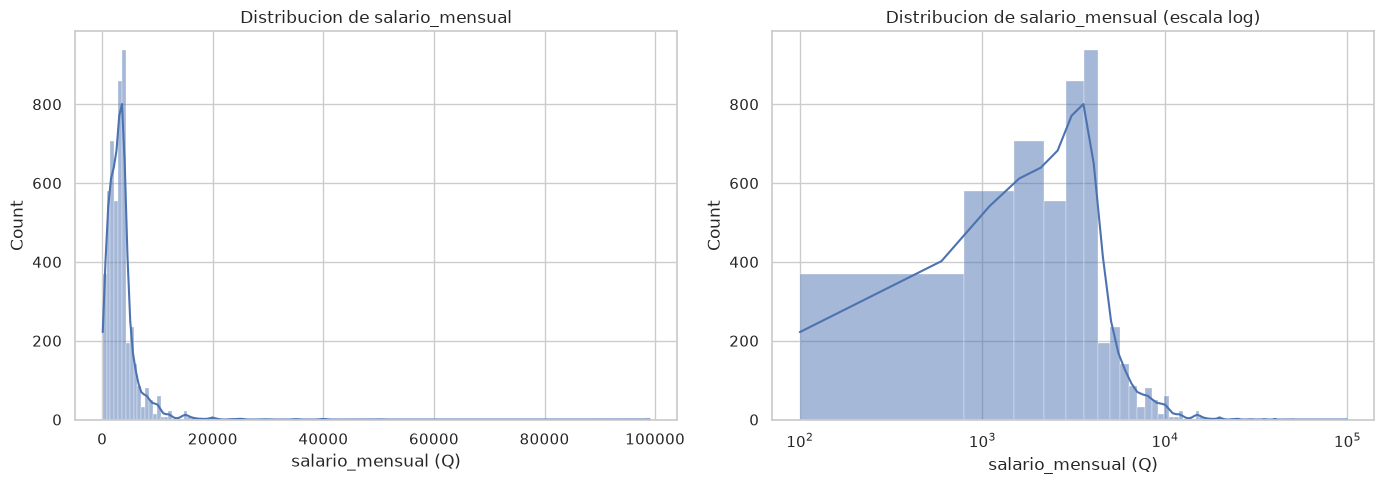

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eda.plot_salary_distribution(df_2025, log_scale=False, ax=axes[0])
eda.plot_salary_distribution(df_2025, log_scale=True, ax=axes[1])
plt.tight_layout()
plt.show()


La escala logarítmica en el segundo panel es solo para visualizar mejor la
cola derecha de la distribución; el objetivo del modelado sigue expresado en
quetzales sin transformar.

In [13]:
salario_medio_mediana = eda.median_by_group(df_2025, "nivel_educativo")
salario_medio_mediana


,nivel_educativo,n,mediana,media
0,7,60,12000.0,14452.266667
1,6,771,10000.0,11409.269780
2,5,6818,5000.0,5965.295248
3,4,16851,3600.0,3796.407988
4,3,8249,2800.0,2730.200267
5,2,15822,2200.0,2307.956390
6,1,459,2160.0,2241.897603
7,0,3995,1500.0,1767.091114


Salario por categoria_ocupacional:
categoria_ocupacional     n  mediana       media
                    1  6575   5000.0 5971.534449
                    2 28702   3560.0 3875.139642
                    3 13842   1800.0 1878.609377
                    4  3906   1000.0 1265.744240


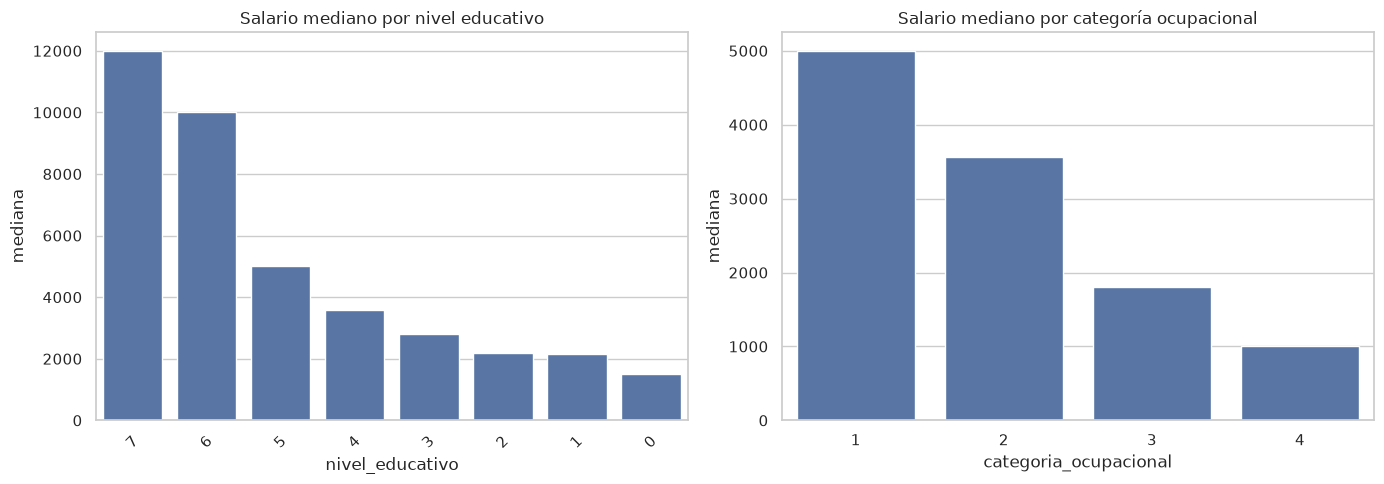

In [14]:
data_edu = eda.median_by_group(df_2025, "nivel_educativo")
data_cat = eda.median_by_group(df_2025, "categoria_ocupacional")
print("Salario por categoria_ocupacional:")
print(data_cat.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
import seaborn as sns
sns.barplot(data=data_edu, x="nivel_educativo", y="mediana", ax=axes[0])
axes[0].set_title("Salario mediano por nivel educativo")
axes[0].tick_params(axis="x", rotation=45)
sns.barplot(data=data_cat, x="categoria_ocupacional", y="mediana", ax=axes[1])
axes[1].set_title("Salario mediano por categoría ocupacional")
plt.tight_layout()
plt.show()


In [15]:
evolucion = eda.median_salary_by_period(df_2025)
evolucion


,periodo_archivo,n,mediana_salario
0,2025T1,13419,3000.0
1,2025T2,13492,3000.0
2,2025T3,13450,3200.0
3,2025T4,12664,3200.0


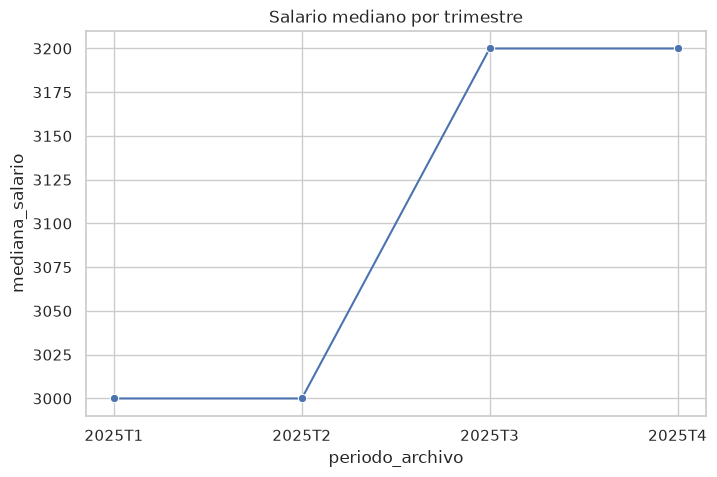

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=evolucion, x="periodo_archivo", y="mediana_salario", marker="o", ax=ax)
ax.set_title("Salario mediano por trimestre")
plt.show()


### Preguntas — Sección 2

**¿Cómo se distribuyen los registros entre categorías ocupacionales,
niveles educativos y dominios?**

- *Categoría ocupacional*: predominan los empleados de empresa privada
  (código 2, 54.1% — 28,702 registros), seguidos por jornaleros/peones
  (código 3, 26.1%), empleados de gobierno (código 1, 12.4%) y servicio
  doméstico (código 4, 7.4%).
- *Nivel educativo*: la mayoría se concentra en diversificado (código 4,
  31.8%) y primaria (código 2, 29.8%), seguido de básico (código 3,
  15.6%) y superior (código 5, 12.9%). Los extremos —sin educación
  (código 0, 7.5%), maestría (1.5%) y doctorado (0.1%)— son minoritarios.
- *Dominio*: Urbano Metropolitano (41.6%) y Resto Urbano (38.0%) concentran
  la mayor parte de la muestra; Rural Nacional es el menor (20.4%).

**¿El salario presenta una distribución simétrica o asimétrica?**

Claramente asimétrica positiva (cola larga a la derecha), como se ve en el
histograma en escala natural y se confirma comparando media y mediana.

**¿Qué diferencia existe entre su media y su mediana?**

Media = Q3,421.68 vs. mediana = Q3,000.00, una diferencia de Q421.68
(≈14% por encima de la mediana). Que la media supere a la mediana es
justamente el efecto de la asimetría positiva: un grupo relativamente
pequeño de salarios muy altos (hasta Q99,000, muy por encima del
percentil 95 de Q8,000) arrastra la media hacia arriba sin mover la
mediana, que es robusta a esos valores extremos.

**¿Cómo varía el salario mediano entre niveles educativos y categorías
ocupacionales?**

Por nivel educativo la relación es monótona creciente: NINGUNO (mediana
Q1,500) < PREPRIMARIA (Q2,160) < PRIMARIA (Q2,200) < BÁSICO (Q2,800) <
DIVERSIFICADO (Q3,600) < SUPERIOR (Q5,000) < MAESTRÍA (Q10,000) <
DOCTORADO (Q12,000) — cada nivel educativo adicional está asociado a un
salario mediano mayor, con saltos particularmente grandes al pasar de
diversificado a superior y de superior a maestría. Por categoría
ocupacional, el gráfico de barras muestra que empleados de gobierno y de
empresa privada tienen salarios medianos más altos que jornaleros/peones y
servicio doméstico, consistente con la naturaleza más informal/manual de
estas dos últimas categorías.

**¿Cómo cambian el tamaño de la muestra analítica y el salario mediano
entre trimestres?**

El tamaño de la muestra analítica por trimestre es bastante estable
(13,419 / 13,492 / 13,450 / 12,664 registros en 2025T1–T4, con una caída
en T4). El salario mediano se mantiene en Q3,000 en T1 y T2, y sube a
Q3,200 en T3 y T4 — un incremento leve pero consistente a lo largo del
año, sin cambios drásticos trimestre a trimestre.

## 3. Relaciones entre variables numéricas (5 pts)

In [17]:
corr_cols = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
corr_matrix = eda.correlation_matrix(df_2025, corr_cols)
corr_matrix


26/09/29 20:21:25 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/29 20:21:25 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS



,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000000,0.147249,0.179574,0.075665
edad,0.147249,1.000000,0.486713,-0.105378
antiguedad,0.179574,0.486713,1.000000,-0.062256
horas_semanales,0.075665,-0.105378,-0.062256,1.000000


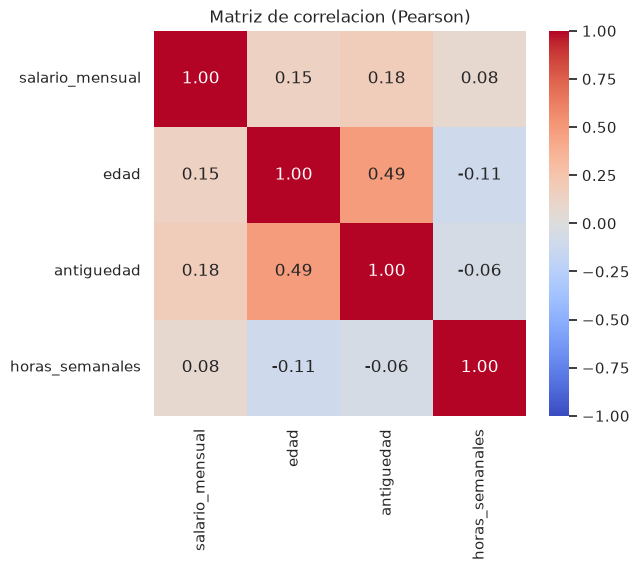

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
eda.plot_correlation_heatmap(corr_matrix, ax=ax)
plt.show()


**¿Qué variables presentan mayor asociación lineal con el salario?**
_(Leer la fila/columna `salario_mensual` de la matriz.)_

**¿Existe relación entre edad y antigüedad?**
_(Leer la celda `edad`/`antiguedad`; es esperable una correlación positiva
moderada, ya que a mayor edad hay más oportunidad de acumular antigüedad.)_

## 4. Segmentación de perfiles mediante KMeans (10 pts)

Se evalúa la segmentación usando los predictores numéricos disponibles
(`edad`, `antiguedad`, `horas_semanales`). Se incluye una comparación
incluyendo y excluyendo `salario_mensual` como variable de clustering, para
discutir si aporta o si domina la segmentación (por su escala/asimetría).

In [19]:
cluster_features_sin_salario = ["edad", "antiguedad", "horas_semanales"]
cluster_features_con_salario = cluster_features_sin_salario + ["salario_mensual"]

df_cluster_input = df_2025.select(*cluster_features_con_salario).na.drop()

resultados_k_sin_salario, modelos_sin_salario = clustering.evaluate_k_candidates(
    df_cluster_input, cluster_features_sin_salario, k_values=[2, 3, 4, 5]
)
resultados_k_con_salario, modelos_con_salario = clustering.evaluate_k_candidates(
    df_cluster_input, cluster_features_con_salario, k_values=[2, 3, 4, 5]
)

print("Silhouette sin salario:")
display(resultados_k_sin_salario)
print("Silhouette con salario:")
display(resultados_k_con_salario)


Silhouette sin salario:


,k,silhouette
0,2,0.555620
1,3,0.470509
2,4,0.473619
3,5,0.442416


Silhouette con salario:


,k,silhouette
0,2,0.513335
1,3,0.362931
2,4,0.402030
3,5,0.413729


Seleccionar el mejor `K` según el criterio de silhouette (mayor es mejor,
rango [-1, 1]); documentar aquí la elección final del equipo y la
justificación (p.ej. mejor silhouette + interpretabilidad de los perfiles).

In [20]:
K_SELECCIONADO = 3  # elegido por silhouette + interpretabilidad (ver justificacion abajo)
FEATURES_SELECCIONADAS = cluster_features_sin_salario  # se excluye salario (ver justificacion abajo)

best_cluster_model = modelos_sin_salario[K_SELECCIONADO]
df_clustered = best_cluster_model.transform(df_cluster_input)

perfiles = clustering.cluster_profile(df_clustered, FEATURES_SELECCIONADAS)
perfiles


,cluster,n,avg_edad,avg_antiguedad,avg_horas_semanales
0,0,11831,52.177753,15.661222,40.175218
1,1,30971,30.000775,2.458036,39.851539
2,2,10223,31.238971,3.261380,72.962438


### Descripción de perfiles

Se eligió **K = 3** usando como criterio la combinación de silhouette e
interpretabilidad: K = 2 tiene el mayor silhouette (0.556) pero produce una
segmentación demasiado gruesa (solo separa "jóvenes" de "mayores"); K = 3
mantiene un silhouette razonable (0.471, muy cercano al de K = 4) y da tres
perfiles claramente diferenciables y accionables. K = 4 y K = 5 no mejoran
la separación (silhouette 0.474 y 0.442) y añaden clusters redundantes.

Con base en `perfiles` (variables sin estandarizar, para facilitar la
lectura):

- **Cluster 0 — Personal senior/veterano** (n = 11,831): edad promedio
  ≈ 52 años, antigüedad promedio ≈ 15.7 años, jornada ≈ 40 horas/semana.
  Trabajadores de mayor edad con largas trayectorias en su empleo actual y
  jornada estándar.
- **Cluster 1 — Entrada reciente al mercado laboral** (n = 30,971, el grupo
  más numeroso): edad promedio = 30 años, antigüedad promedio ≈ 2.5 años,
  jornada ≈ 40 horas/semana. Trabajadores jóvenes con poca antigüedad en su
  puesto actual y jornada estándar; es el perfil predominante en la muestra.
- **Cluster 2 — Jornada extendida** (n = 10,223): edad promedio ≈ 31 años,
  antigüedad promedio ≈ 3.3 años, jornada ≈ 73 horas/semana. Trabajadores
  jóvenes, con antigüedad similar al cluster 1, pero con una carga horaria
  casi el doble de la jornada estándar — posible indicio de pluriempleo,
  turnos extendidos o sectores con jornadas atípicas (p.ej. comercio o
  servicio doméstico).

Sobre incluir `salario_mensual` como variable de clustering: al probarlo
(`resultados_k_con_salario`), el silhouette bajó en todos los K (p.ej. 0.513
vs. 0.556 en K = 2, y 0.363 vs. 0.471 en K = 3). Esto ocurre porque el
salario tiene una escala y una asimetría muy distintas a las horas/edad/
antigüedad, por lo que domina la distancia euclidiana estandarizada y
produce clusters menos compactos. Se decidió **no incluir el salario** como
variable de segmentación: los perfiles buscan describir *condiciones
laborales* (edad, antigüedad, jornada), y el salario se analiza después
como variable de salida asociada a cada perfil, no como insumo de la
segmentación.

## 5. Pipeline de regresión lineal (20 pts)

In [21]:
df_train_full = io_utils.read_parquet(spark, TRAIN_2025_PARQUET)

df_train, df_val = df_train_full.randomSplit([0.8, 0.2], seed=RANDOM_SEED)
df_train.cache()
df_val.cache()
print(f"train: {df_train.count():,}  val: {df_val.count():,}")


train: 42,574  val: 10,451


In [22]:
lr_configs = [
    ("lr_ridge", {"reg_param": 0.1, "elastic_net_param": 0.0}),
    ("lr_elasticnet", {"reg_param": 0.1, "elastic_net_param": 0.5}),
    ("lr_lasso", {"reg_param": 0.05, "elastic_net_param": 1.0}),
]

lr_pipelines = [
    (name, params, modeling.build_linear_regression_pipeline(**params))
    for name, params in lr_configs
]

lr_runs, best_lr_run = modeling.run_configs(lr_pipelines, df_train, df_val)
modeling.runs_to_table(lr_runs)


26/09/29 20:21:55 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


,config,reg_param,elastic_net_param,mae,rmse,r2
0,lr_ridge,0.10,0.0,1263.753571,2441.543916,0.375623
1,lr_elasticnet,0.10,0.5,1263.742307,2441.546878,0.375622
2,lr_lasso,0.05,1.0,1263.744282,2441.546130,0.375622


In [23]:
print("Mejor configuracion (regresion lineal):", best_lr_run.name, best_lr_run.params)
print(best_lr_run.metrics)

best_lr_run.model.write().overwrite().save(str(PROCESSED_DIR / "models" / "linear_regression_best"))


Mejor configuracion (regresion lineal): lr_ridge {'reg_param': 0.1, 'elastic_net_param': 0.0}
{'mae': 1263.7535714194596, 'rmse': 2441.54391551695, 'r2': 0.37562335152377335}


Interpretar MAE, RMSE y R² frente a un **modelo de referencia** simple
(ej. predecir siempre la media/mediana del salario de entrenamiento):

Las tres configuraciones de regularización dan resultados prácticamente
idénticos (RMSE ≈ 2,441.5, R² ≈ 0.376): con solo seis predictores y una
escala moderada de regularización (`regParam` ≤ 0.1), la penalización L1/L2
casi no cambia los coeficientes, así que Ridge, ElasticNet y Lasso
convergen a soluciones muy similares. Se seleccionó `lr_ridge`
(`regParam=0.1`, `elasticNetParam=0.0`) por tener el menor RMSE de
validación, aunque por una diferencia mínima.

In [24]:
from pyspark.sql import functions as F

media_train = df_train.select(F.mean(TARGET_COLUMN)).first()[0]
baseline_val = df_val.withColumn("prediction", F.lit(media_train))
baseline_metrics = modeling.evaluate_predictions(baseline_val)
print("Modelo de referencia (media):", baseline_metrics)


Modelo de referencia (media): {'mae': 1723.929101961969, 'rmse': 3090.244202301533, 'r2': -0.00023759122999544857}


## 6. Pipeline de Random Forest (20 pts)

In [25]:
rf_configs = [
    ("rf_50_8", {"num_trees": 50, "max_depth": 8}),
    ("rf_100_10", {"num_trees": 100, "max_depth": 10}),
]

rf_pipelines = [
    (name, params, modeling.build_random_forest_pipeline(**params))
    for name, params in rf_configs
]

rf_runs, best_rf_run = modeling.run_configs(rf_pipelines, df_train, df_val)
modeling.runs_to_table(rf_runs)



[Stage 919:>                                                      (0 + 16) / 16]



26/09/29 20:22:16 WARN DAGScheduler: Broadcasting large task binary with size 1027.2 KiB



[Stage 925:========================>                               (7 + 9) / 16]



26/09/29 20:22:16 WARN DAGScheduler: Broadcasting large task binary with size 1729.2 KiB



[Stage 927:===================================================>   (15 + 1) / 16]



...


[Stage 964:========================>                               (7 + 9) / 16]
26/09/29 20:22:29 WARN DAGScheduler: Broadcasting large task binary with size 1201.6 KiB


26/09/29 20:22:30 WARN DAGScheduler: Broadcasting large task binary with size 8.5 MiB



[Stage 966:===================================================>   (15 + 1) / 16]
26/09/29 20:22:33 WARN DAGScheduler: Broadcasting large task binary with size 1764.5 KiB



[Stage 967:>                                                      (0 + 16) / 16]



,config,num_trees,max_depth,mae,rmse,r2
0,rf_50_8,50,8,1152.186056,2291.968948,0.449782
1,rf_100_10,100,10,1138.287862,2243.290339,0.472905


In [26]:
print("Mejor configuracion (random forest):", best_rf_run.name, best_rf_run.params)
print(best_rf_run.metrics)

best_rf_run.model.write().overwrite().save(str(PROCESSED_DIR / "models" / "random_forest_best"))


Mejor configuracion (random forest): rf_100_10 {'num_trees': 100, 'max_depth': 10}
{'mae': 1138.2878621237603, 'rmse': 2243.290338915616, 'r2': 0.47290542826325355}


**¿Cuál algoritmo obtuvo mejores resultados en validación?**

Random Forest (`rf_100_10`, 100 árboles, profundidad máxima 10) supera a la
regresión lineal en las tres métricas de validación: RMSE 2,243.3 frente a
2,441.5 (≈8% menor), MAE 1,138.3 frente a 1,263.8, y R² 0.473 frente a
0.376. Ambos modelos superan claramente al modelo de referencia (predecir
la media: RMSE 3,090.2, R² ≈ 0), lo que confirma que las seis variables sí
aportan poder predictivo, pero ninguno de los dos explica más de la mitad
de la varianza del salario — esperable dado que el salario también depende
de factores no observados aquí (sector económico, tamaño de la empresa,
habilidades específicas, negociación individual, etc.).

La ventaja de Random Forest es consistente con la naturaleza de los datos:
la relación entre antigüedad/edad y salario no es estrictamente lineal (por
ejemplo, los rendimientos de la antigüedad probablemente se aplanan después
de cierto punto), y puede haber interacciones entre nivel educativo,
categoría ocupacional y dominio que un modelo lineal aditivo no captura
pero que los árboles sí pueden aproximar mediante particiones sucesivas.

## 7. Entrenamiento final y evaluación en 2026 (20 pts)

In [27]:
df_test_2026 = io_utils.read_parquet(spark, TEST_2026_PARQUET)

pred_lr_test = best_lr_run.model.transform(df_test_2026)
pred_rf_test = best_rf_run.model.transform(df_test_2026)

metrics_lr_test = modeling.evaluate_predictions(pred_lr_test)
metrics_rf_test = modeling.evaluate_predictions(pred_rf_test)

comparacion_test = pd.DataFrame(
    [
        {"modelo": "Regresion Lineal", **metrics_lr_test},
        {"modelo": "Random Forest", **metrics_rf_test},
    ]
)
comparacion_test


,modelo,mae,rmse,r2
0,Regresion Lineal,1239.626202,2165.984443,0.429557
1,Random Forest,1105.124548,1971.385891,0.527453


## 8. Visualización y análisis de errores (15 pts)

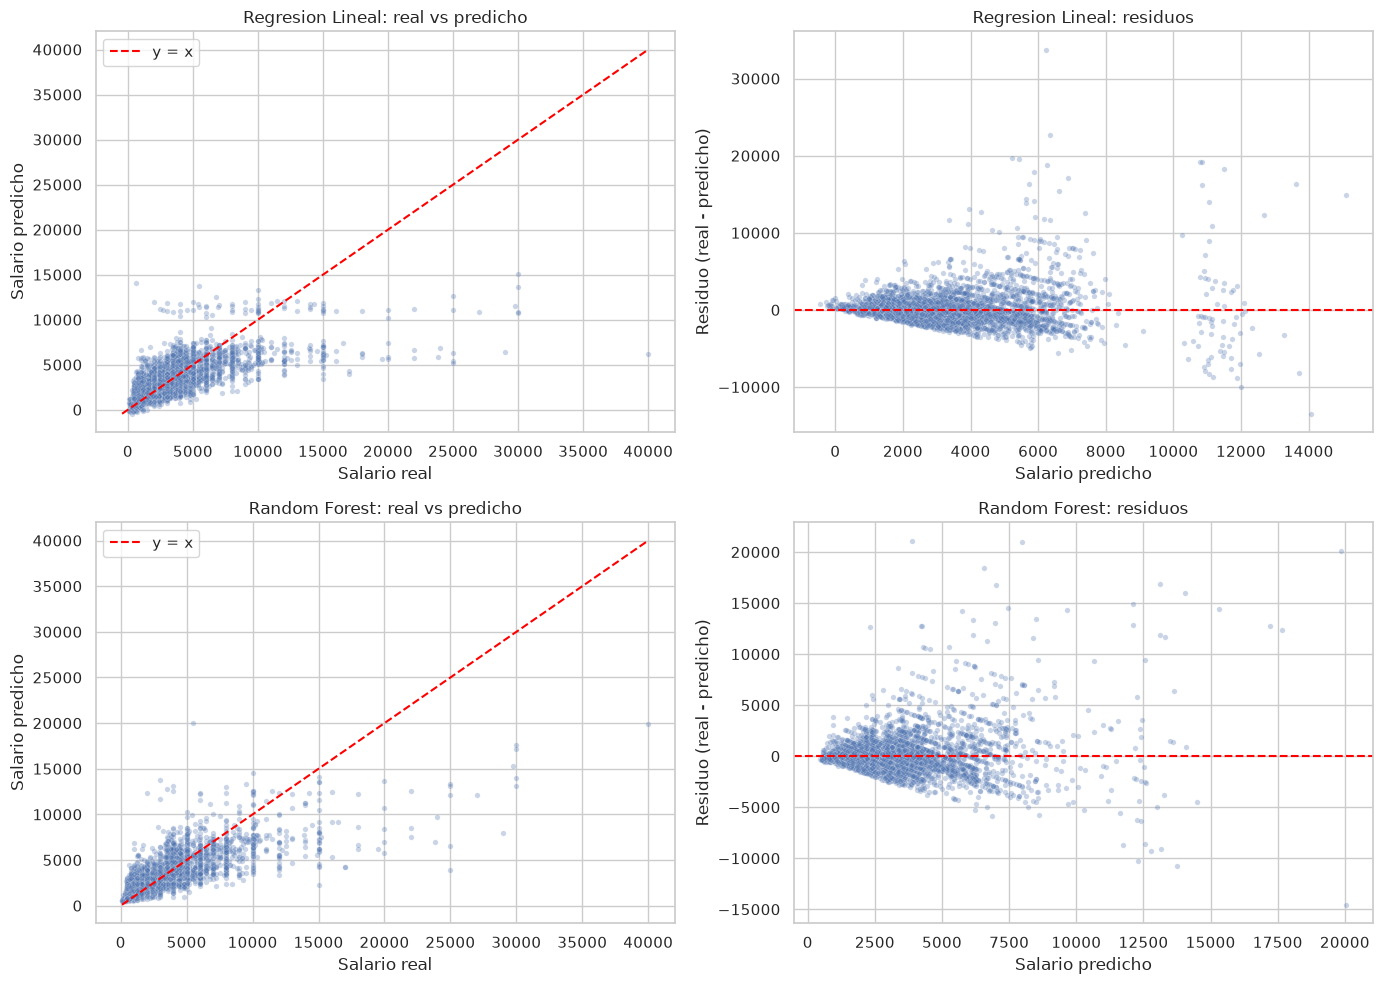

In [28]:
pred_lr_res = evaluation.add_residuals(pred_lr_test)
pred_rf_res = evaluation.add_residuals(pred_rf_test)

sample_lr = evaluation.sample_for_plots(pred_lr_res)
sample_rf = evaluation.sample_for_plots(pred_rf_res)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
evaluation.plot_actual_vs_predicted(sample_lr, "Regresion Lineal: real vs predicho", ax=axes[0, 0])
evaluation.plot_residuals(sample_lr, "Regresion Lineal: residuos", ax=axes[0, 1])
evaluation.plot_actual_vs_predicted(sample_rf, "Random Forest: real vs predicho", ax=axes[1, 0])
evaluation.plot_residuals(sample_rf, "Random Forest: residuos", ax=axes[1, 1])
plt.tight_layout()
plt.show()


In [29]:
mae_edu_lr = evaluation.error_by_group(pred_lr_res, "nivel_educativo")
mae_dom_lr = evaluation.error_by_group(pred_lr_res, "dominio")
mae_edu_rf = evaluation.error_by_group(pred_rf_res, "nivel_educativo")
mae_dom_rf = evaluation.error_by_group(pred_rf_res, "dominio")

print("MAE / error medio por nivel educativo — Regresion Lineal")
display(mae_edu_lr)
print("MAE / error medio por dominio — Regresion Lineal")
display(mae_dom_lr)
print("MAE / error medio por nivel educativo — Random Forest")
display(mae_edu_rf)
print("MAE / error medio por dominio — Random Forest")
display(mae_dom_rf)


MAE / error medio por nivel educativo — Regresion Lineal



[Stage 1048:==============================>                        (9 + 7) / 16]



,nivel_educativo,n,mae,error_medio
0,4,4117,1108.973432,113.709480
1,2,3957,870.426981,56.895525
2,3,2164,896.196227,137.110175
3,5,1729,2557.362285,324.754616
4,0,1016,823.985987,110.709782
5,6,183,5530.717569,-19.715917
6,1,80,734.477570,73.102132
7,7,12,12995.308081,6633.681296


MAE / error medio por dominio — Regresion Lineal


,dominio,n,mae,error_medio
0,1,5632,1444.916217,157.655449
1,2,4846,1188.215824,138.543857
2,3,2780,913.346105,67.090330


MAE / error medio por nivel educativo — Random Forest


,nivel_educativo,n,mae,error_medio
0,4,4117,1017.292200,131.887286
1,2,3957,755.145793,37.196953
2,3,2164,827.239294,130.679652
3,5,1729,2289.856247,319.962013
4,0,1016,656.467938,-60.300846
5,6,183,4738.778367,-133.535131
6,1,80,630.955923,-143.904167
7,7,12,11790.478774,6791.692746


MAE / error medio por dominio — Random Forest


,dominio,n,mae,error_medio
0,1,5632,1319.678331,191.540626
1,2,4846,1046.575653,80.708746
2,3,2780,772.520606,14.599782


In [30]:
percentiles_salario_test = df_test_2026.approxQuantile(
    "salario_mensual", [0.25, 0.5, 0.75, 0.9, 0.95, 0.99], 0.001
)
print("Percentiles 25/50/75/90/95/99 del salario de prueba:", percentiles_salario_test)

pred_lr_pd_full = pred_lr_res.select("salario_mensual", "prediction", "residuo").toPandas()
alto_umbral = percentiles_salario_test[4]  # p95
sesgo_altos = pred_lr_pd_full.loc[pred_lr_pd_full["salario_mensual"] >= alto_umbral, "residuo"].mean()
print("Error medio (residuo) en salarios >= p95:", sesgo_altos)


Percentiles 25/50/75/90/95/99 del salario de prueba: [2000.0, 3200.0, 4066.0, 6000.0, 8000.0, 15000.0]


Error medio (residuo) en salarios >= p95: 4921.395742366023


### Discusión final

**Evaluación en 2026T1 (prueba final):** Random Forest vuelve a superar a
la regresión lineal fuera de muestra: RMSE 1,971.4 vs. 2,166.0, MAE 1,105.1
vs. 1,239.6, R² 0.527 vs. 0.430. Ambos modelos generalizan razonablemente
del período de entrenamiento/validación (2025) al de prueba (2026T1) — de
hecho las métricas de prueba son *mejores* que las de validación para
ambos modelos, lo que sugiere que 2026T1 no presenta un cambio estructural
fuerte respecto a 2025 para esta población. Random Forest es el modelo que
mejor generaliza de los dos.

**Definición de residuo:** en todo el notebook, residuo = salario real −
salario predicho. Un residuo positivo indica que el modelo **subestimó**
el salario real; uno negativo, que lo **sobreestimó**.

**¿Existe una tendencia a subestimar salarios altos?** Sí, y es
sistemática. Los percentiles de salario en la muestra de prueba son:
P25 = Q2,000, P50 = Q3,200, P75 = Q4,066, P90 = Q6,000, P95 = Q8,000,
P99 = Q15,000. Para los registros con salario ≥ P95 (los asalariados mejor
pagados), el error medio (residuo) de la regresión lineal es **+4,921.4**:
en promedio el modelo subestima el salario real de este grupo por casi
Q5,000. Esto es un patrón típico de modelos entrenados por mínimos
cuadrados/impureza sobre una variable con fuerte asimetría positiva: la
mayoría de la masa de datos está entre Q1,800 y Q4,000, así que el modelo
"aprende" a predecir bien ese rango y sistemáticamente se queda corto en la
cola derecha, donde hay pocas observaciones pero salarios mucho más altos y
dispersos. Los gráficos de real vs. predicho muestran esto como una
dispersión de puntos que se aleja de la línea y = x hacia abajo a medida
que el salario real crece, y los gráficos de residuos muestran una
concentración de residuos positivos grandes en la zona de predicciones
altas.

**¿Qué grupos presentan mayor error?** Por nivel educativo, el grupo
**SUPERIOR** (código 5, universitario) tiene el MAE más alto de todos los
niveles (≈ Q2,557 con regresión lineal, ≈ Q2,290 con Random Forest) y
también el mayor error medio con signo (+325 y +320 respectivamente): es el
grupo con salarios más altos y más dispersos, y ambos modelos tienden a
subestimarlo. En el otro extremo, PRIMARIA (código 2) tiene el menor MAE
(≈ Q870 / Q755) y el menor sesgo, consistente con salarios más bajos y más
homogéneos. Por dominio, **Urbano Metropolitano** concentra el mayor MAE
(≈ Q1,445 / Q1,320) y el mayor sesgo de subestimación (+158 / +192),
mientras que Rural Nacional tiene el menor error (≈ Q913 / Q773) — el
dominio metropolitano combina salarios más altos en promedio con mayor
dispersión (más heterogeneidad de sectores/ocupaciones), lo que dificulta
la predicción puntual.

**Síntesis:** las seis variables usadas (edad, antigüedad, horas
semanales, nivel educativo, categoría ocupacional y dominio) explican una
parte significativa pero limitada de la variación del salario mensual
(R² ≈ 0.43–0.53 según el modelo), y Random Forest captura mejor las
relaciones no lineales/interacciones que la regresión lineal. El hallazgo
más relevante para la interpretación de negocio es que **ambos modelos
subestiman sistemáticamente a los asalariados de mayores ingresos**,
particularmente a quienes tienen educación superior y están en el dominio
metropolitano; cualquier uso de estos modelos (p.ej. para detectar
subpagos o para estimar brechas salariales) debe tener en cuenta este
sesgo y no debe interpretarse como una recomendación normativa de cuánto
debería ganar una persona — las asociaciones encontradas son descriptivas
y no implican relaciones causales. Los resultados tampoco son
representativos de la población guatemalteca completa: provienen de un
análisis no ponderado (sin usar `FACTOR`) sobre asalariados con salario
positivo registrado, un subconjunto específico de la fuerza laboral.